In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

processed_dir = Path("../data/processed")

# Historical central death rates
mx = pd.read_csv(processed_dir / "us_total_mortality_matrix.csv", index_col=0)

# Forecast central death rates
forecast_mx = pd.read_csv(processed_dir / "forecast_mx_2050.csv", index_col=0)

# Convert index and columns to integers
mx.index = mx.index.astype(int)
mx.columns = mx.columns.astype(int)

forecast_mx.index = forecast_mx.index.astype(int)
forecast_mx.columns = forecast_mx.columns.astype(int)

# Use ages 0–100 to match the refined Lee-Carter model
mx_100 = mx.loc[0:100]
forecast_mx_100 = forecast_mx.loc[0:100]

print(mx_100.shape)
print(forecast_mx_100.shape)

(101, 92)
(101, 26)


In [2]:
def build_life_table(mx_col, radix=100000):
    """
    Build an approximate period life table from single-year central death rates.

    Parameters
    ----------
    mx_col : pandas Series
        Central death rates by age for one year.
    radix : int
        Starting population at age 0.

    Returns
    -------
    life_table : pandas DataFrame
        Life table with mx, qx, lx, dx, Lx, Tx, and ex.
    """
    
    mx_col = mx_col.astype(float)
    ages = mx_col.index.to_numpy()
    omega = ages.max()
    
    # Convert central death rate to death probability
    qx = 1 - np.exp(-mx_col)
    qx = qx.clip(lower=0, upper=1)
    
    # Treat the final age as an open terminal age group
    qx.loc[omega] = 1.0
    
    lx = pd.Series(index=ages, dtype=float)
    dx = pd.Series(index=ages, dtype=float)
    
    lx.loc[ages[0]] = radix
    
    for i, age in enumerate(ages):
        dx.loc[age] = lx.loc[age] * qx.loc[age]
        
        if age != omega:
            next_age = ages[i + 1]
            lx.loc[next_age] = lx.loc[age] - dx.loc[age]
    
    Lx = pd.Series(index=ages, dtype=float)
    
    for i, age in enumerate(ages):
        if age != omega:
            next_age = ages[i + 1]
            Lx.loc[age] = 0.5 * (lx.loc[age] + lx.loc[next_age])
        else:
            # Open-age approximation
            Lx.loc[age] = lx.loc[age] / mx_col.loc[age]
    
    Tx = Lx.iloc[::-1].cumsum().iloc[::-1]
    ex = Tx / lx
    
    life_table = pd.DataFrame({
        "m_x": mx_col,
        "q_x": qx,
        "l_x": lx,
        "d_x": dx,
        "L_x": Lx,
        "T_x": Tx,
        "e_x": ex
    })
    
    return life_table

In [3]:
lt_2024 = build_life_table(mx_100[2024])

lt_2024.head()

,m_x,q_x,l_x,d_x,L_x,T_x,e_x
0,0.005528,0.005513,100000.000000,551.274872,99724.362564,7.929157e+06,79.291566
1,0.000395,0.000395,99448.725128,39.274489,99429.087883,7.829432e+06,78.728332
2,0.000257,0.000257,99409.450638,25.544946,99396.678165,7.730003e+06,77.759239
3,0.000210,0.000210,99383.905692,20.868429,99373.471478,7.630607e+06,76.779097
4,0.000169,0.000169,99363.037263,16.790934,99354.641796,7.531233e+06,75.795117


In [4]:
historical_e0 = {}
historical_e65 = {}

for year in mx_100.columns:
    lt = build_life_table(mx_100[year])
    historical_e0[year] = lt.loc[0, "e_x"]
    historical_e65[year] = lt.loc[65, "e_x"]

historical_e0 = pd.Series(historical_e0, name="e0")
historical_e65 = pd.Series(historical_e65, name="e65")


forecast_e0 = {}
forecast_e65 = {}

for year in forecast_mx_100.columns:
    lt = build_life_table(forecast_mx_100[year])
    forecast_e0[year] = lt.loc[0, "e_x"]
    forecast_e65[year] = lt.loc[65, "e_x"]

forecast_e0 = pd.Series(forecast_e0, name="forecast_e0")
forecast_e65 = pd.Series(forecast_e65, name="forecast_e65")

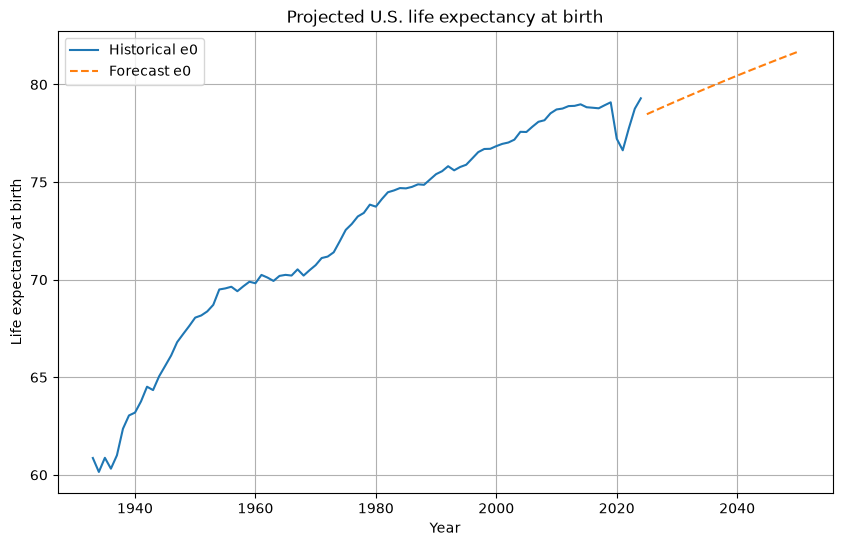

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(historical_e0.index, historical_e0.values, label="Historical e0")
plt.plot(forecast_e0.index, forecast_e0.values, linestyle="--", label="Forecast e0")

plt.xlabel("Year")
plt.ylabel("Life expectancy at birth")
plt.title("Projected U.S. life expectancy at birth")
plt.legend()
plt.grid(True)
plt.show()

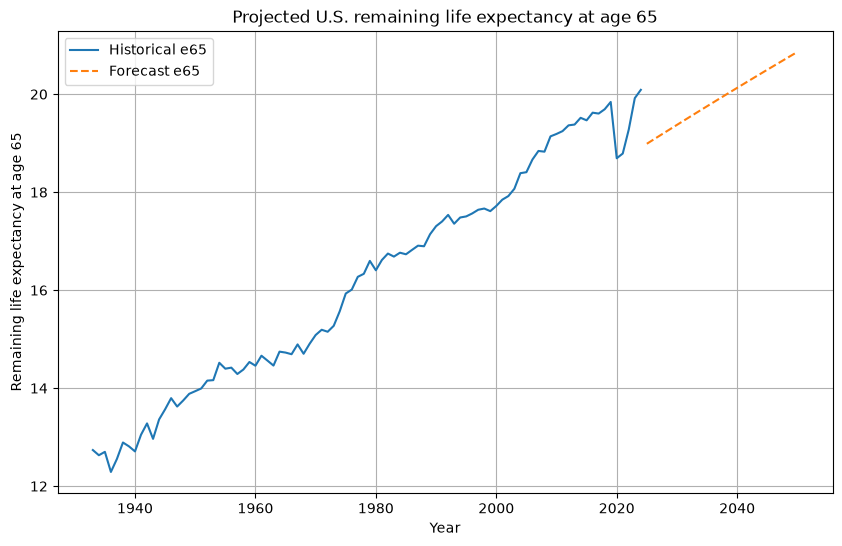

In [6]:
plt.figure(figsize=(10, 6))

plt.plot(historical_e65.index, historical_e65.values, label="Historical e65")
plt.plot(forecast_e65.index, forecast_e65.values, linestyle="--", label="Forecast e65")

plt.xlabel("Year")
plt.ylabel("Remaining life expectancy at age 65")
plt.title("Projected U.S. remaining life expectancy at age 65")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
life_expectancy_summary = pd.DataFrame({
    "e0_forecast": forecast_e0,
    "e65_forecast": forecast_e65
})

life_expectancy_summary.loc[[2030, 2040, 2050]]

,e0_forecast,e65_forecast
2030,79.156665,19.373430
2040,80.452436,20.129191
2050,81.666557,20.862080


In [8]:
display(life_expectancy_summary.loc[[2030, 2040, 2050]])
print("Historical e0 in 2024:", historical_e0.loc[2024])
print("Forecast e0 in 2050:", forecast_e0.loc[2050])

,e0_forecast,e65_forecast
2030,79.156665,19.373430
2040,80.452436,20.129191
2050,81.666557,20.862080


Historical e0 in 2024: 79.2915663573604
Forecast e0 in 2050: 81.66655709243658


## Jump-Off Adjustment

The initial Lee-Carter forecast may not connect smoothly to the historical life expectancy series because the fitted mortality rates in the final observed year do not exactly equal the actual observed rates. To avoid this jump-off problem, I use the observed 2024 mortality rates as the forecast starting point and apply the Lee-Carter model only to project future changes in mortality. This makes the forecast begin from the latest actual mortality experience while preserving the model’s projected mortality improvement trend.

In [9]:
b_x = pd.read_csv(processed_dir / "b_x_100.csv", index_col=0).squeeze("columns")
k_t = pd.read_csv(processed_dir / "k_t_100.csv", index_col=0).squeeze("columns")
k_forecast = pd.read_csv(processed_dir / "k_t_forecast_2050.csv", index_col=0).squeeze("columns")

b_x.index = b_x.index.astype(int)
k_t.index = k_t.index.astype(int)
k_forecast.index = k_forecast.index.astype(int)

In [10]:
# Use observed 2024 mortality as the jump-off point
base_year = 2024

log_mx_2024 = np.log(mx_100[base_year])
k_2024 = k_t.loc[base_year]

adjusted_forecast_log_mx = pd.DataFrame(
    np.outer(b_x.values, k_forecast.values - k_2024),
    index=b_x.index,
    columns=k_forecast.index
)

adjusted_forecast_log_mx = adjusted_forecast_log_mx.add(log_mx_2024, axis=0)

adjusted_forecast_mx = np.exp(adjusted_forecast_log_mx)

adjusted_forecast_mx.head()

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
Age_num,,,,,,,,,,,,,,,,,,,,,
0,0.005373,0.005223,0.005077,0.004935,0.004797,0.004663,0.004532,0.004406,0.004283,0.004163,...,0.003413,0.003318,0.003225,0.003135,0.003047,0.002962,0.002879,0.002798,0.002720,0.002644
1,0.000382,0.000370,0.000358,0.000346,0.000335,0.000324,0.000313,0.000303,0.000293,0.000283,...,0.000225,0.000217,0.000210,0.000203,0.000197,0.000190,0.000184,0.000178,0.000172,0.000167
2,0.000249,0.000242,0.000235,0.000228,0.000221,0.000215,0.000209,0.000202,0.000196,0.000191,...,0.000155,0.000150,0.000146,0.000142,0.000137,0.000133,0.000129,0.000126,0.000122,0.000118
3,0.000204,0.000198,0.000192,0.000187,0.000181,0.000176,0.000171,0.000166,0.000161,0.000157,...,0.000128,0.000124,0.000121,0.000117,0.000114,0.000110,0.000107,0.000104,0.000101,0.000098
4,0.000164,0.000159,0.000155,0.000150,0.000146,0.000142,0.000138,0.000134,0.000130,0.000126,...,0.000103,0.000100,0.000097,0.000094,0.000091,0.000089,0.000086,0.000084,0.000081,0.000079


In [11]:
adjusted_forecast_e0 = {}
adjusted_forecast_e65 = {}

for year in adjusted_forecast_mx.columns:
    lt = build_life_table(adjusted_forecast_mx[year])
    adjusted_forecast_e0[year] = lt.loc[0, "e_x"]
    adjusted_forecast_e65[year] = lt.loc[65, "e_x"]

adjusted_forecast_e0 = pd.Series(adjusted_forecast_e0, name="adjusted_forecast_e0")
adjusted_forecast_e65 = pd.Series(adjusted_forecast_e65, name="adjusted_forecast_e65")

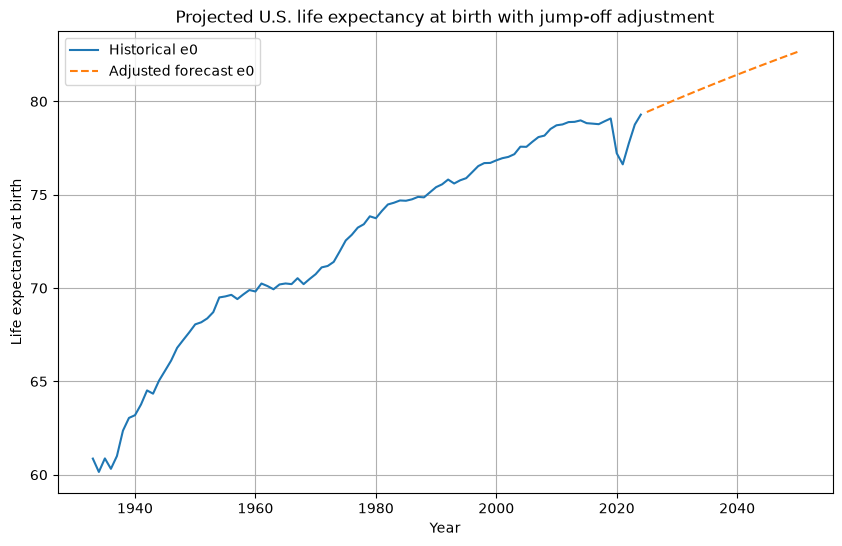

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(historical_e0.index, historical_e0.values, label="Historical e0")
plt.plot(adjusted_forecast_e0.index, adjusted_forecast_e0.values, linestyle="--", label="Adjusted forecast e0")

plt.xlabel("Year")
plt.ylabel("Life expectancy at birth")
plt.title("Projected U.S. life expectancy at birth with jump-off adjustment")
plt.legend()
plt.grid(True)
plt.show()

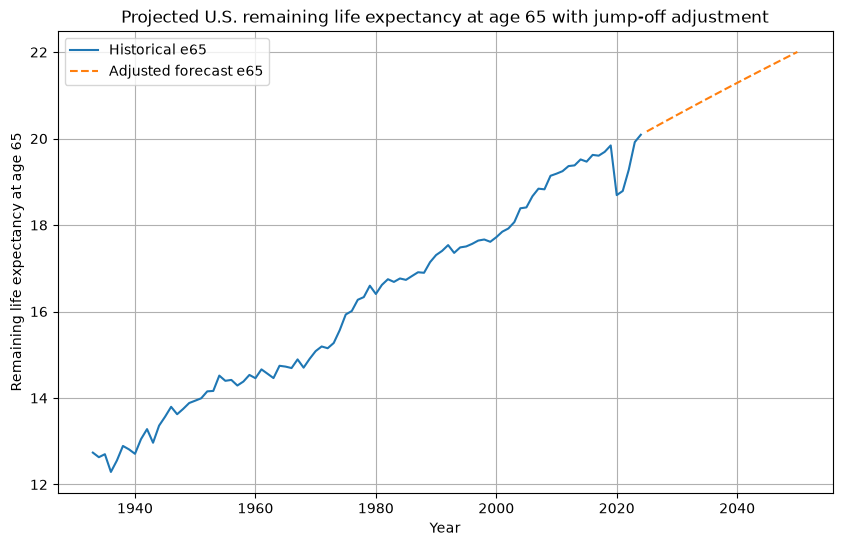

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(historical_e65.index, historical_e65.values, label="Historical e65")
plt.plot(adjusted_forecast_e65.index, adjusted_forecast_e65.values, linestyle="--", label="Adjusted forecast e65")

plt.xlabel("Year")
plt.ylabel("Remaining life expectancy at age 65")
plt.title("Projected U.S. remaining life expectancy at age 65 with jump-off adjustment")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
adjusted_life_expectancy_summary = pd.DataFrame({
    "e0_forecast": adjusted_forecast_e0,
    "e65_forecast": adjusted_forecast_e65
})

display(adjusted_life_expectancy_summary.loc[[2030, 2040, 2050]])

print("Historical e0 in 2024:", historical_e0.loc[2024])
print("Adjusted forecast e0 in 2025:", adjusted_forecast_e0.loc[2025])
print("Adjusted forecast e0 in 2050:", adjusted_forecast_e0.loc[2050])

,e0_forecast,e65_forecast
2030,80.121348,20.545821
2040,81.429101,21.288068
2050,82.649093,22.003696


Historical e0 in 2024: 79.2915663573604
Adjusted forecast e0 in 2025: 79.43231615856855
Adjusted forecast e0 in 2050: 82.64909319415605


In [15]:
adjusted_forecast_mx.to_csv(processed_dir / "adjusted_forecast_mx_2050.csv")
adjusted_forecast_log_mx.to_csv(processed_dir / "adjusted_forecast_log_mx_2050.csv")

adjusted_life_expectancy_summary.to_csv(
    processed_dir / "adjusted_life_expectancy_forecast_2050.csv"
)

print("Saved jump-off adjusted mortality and life expectancy forecasts.")

Saved jump-off adjusted mortality and life expectancy forecasts.


## Forecast Summary

After applying the jump-off adjustment, the projected life expectancy series connects smoothly to the latest observed mortality experience. Under the random-walk-with-drift forecast for the Lee-Carter mortality index, U.S. life expectancy at birth is projected to increase from approximately 79.3 years in 2024 to 82.6 years in 2050. Remaining life expectancy at age 65 is projected to increase to approximately 22.0 years by 2050. These results suggest continued mortality improvement and highlight longevity risk implications for annuity and pension liabilities.

## Sensitivity Analysis: Alternative Drift Assumptions

The baseline forecast uses the average annual change in the Lee-Carter mortality index over the full sample period. However, mortality improvement rates may differ across historical periods. Early years may reflect rapid improvements from reductions in infant mortality and infectious disease mortality, while recent decades may better represent modern mortality trends. Therefore, I compare life expectancy projections under several alternative drift assumptions.

In [16]:
def forecast_k_with_drift_window(k_t, start_year, end_year=2024, forecast_end=2050):
    """
    Forecast k_t using random walk with drift, where drift is estimated
    from a selected historical window.
    """
    
    k_window = k_t.loc[start_year:end_year]
    k_diff = k_window.diff().dropna()
    
    drift = k_diff.mean()
    sigma = k_diff.std()
    
    last_year = k_t.index.max()
    last_k = k_t.loc[last_year]
    
    forecast_years = np.arange(last_year + 1, forecast_end + 1)
    h = np.arange(1, len(forecast_years) + 1)
    
    k_forecast_values = last_k + h * drift
    
    k_forecast = pd.Series(
        k_forecast_values,
        index=forecast_years,
        name=f"k_forecast_{start_year}_{end_year}"
    )
    
    return k_forecast, drift, sigma

In [17]:
scenarios = {
    "Full sample: 1933–2024": (1933, 2024),
    "Recent period: 1970–2024": (1970, 2024),
    "Modern period: 1980–2024": (1980, 2024),
    "Pre-COVID modern: 1980–2019": (1980, 2019)
}

scenario_forecasts = {}
scenario_stats = []

for name, (start, end) in scenarios.items():
    k_forecast_scenario, drift_scenario, sigma_scenario = forecast_k_with_drift_window(
        k_t=k_t,
        start_year=start,
        end_year=end,
        forecast_end=2050
    )
    
    scenario_forecasts[name] = k_forecast_scenario
    
    scenario_stats.append({
        "Scenario": name,
        "Start Year": start,
        "End Year": end,
        "Drift": drift_scenario,
        "Sigma": sigma_scenario
    })

scenario_stats = pd.DataFrame(scenario_stats)

scenario_stats

,Scenario,Start Year,End Year,Drift,Sigma
0,Full sample: 1933–2024,1933,2024,-1.332007,2.346400
1,Recent period: 1970–2024,1970,2024,-1.073157,2.315510
2,Modern period: 1980–2024,1980,2024,-0.904087,2.461397
3,Pre-COVID modern: 1980–2019,1980,2019,-1.069057,1.383989


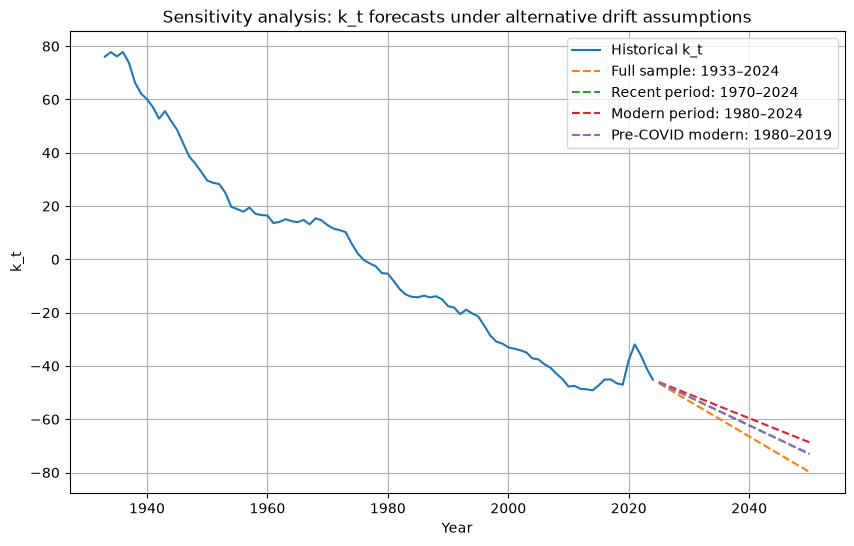

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(k_t.index, k_t.values, label="Historical k_t")

for name, k_forecast_scenario in scenario_forecasts.items():
    plt.plot(
        k_forecast_scenario.index,
        k_forecast_scenario.values,
        linestyle="--",
        label=name
    )

plt.xlabel("Year")
plt.ylabel("k_t")
plt.title("Sensitivity analysis: k_t forecasts under alternative drift assumptions")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
def build_adjusted_mortality_forecast(mx_100, b_x, k_t, k_forecast, base_year=2024):
    """
    Build jump-off adjusted mortality forecast using observed base-year mortality.
    """
    
    log_mx_base = np.log(mx_100[base_year])
    k_base = k_t.loc[base_year]
    
    forecast_log_mx = pd.DataFrame(
        np.outer(b_x.values, k_forecast.values - k_base),
        index=b_x.index,
        columns=k_forecast.index
    )
    
    forecast_log_mx = forecast_log_mx.add(log_mx_base, axis=0)
    forecast_mx = np.exp(forecast_log_mx)
    
    return forecast_mx

In [20]:
sensitivity_results = []

for name, k_forecast_scenario in scenario_forecasts.items():
    mx_forecast_scenario = build_adjusted_mortality_forecast(
        mx_100=mx_100,
        b_x=b_x,
        k_t=k_t,
        k_forecast=k_forecast_scenario,
        base_year=2024
    )
    
    e0_scenario = {}
    e65_scenario = {}
    
    for year in mx_forecast_scenario.columns:
        lt = build_life_table(mx_forecast_scenario[year])
        e0_scenario[year] = lt.loc[0, "e_x"]
        e65_scenario[year] = lt.loc[65, "e_x"]
    
    e0_scenario = pd.Series(e0_scenario)
    e65_scenario = pd.Series(e65_scenario)
    
    sensitivity_results.append({
        "Scenario": name,
        "e0_2030": e0_scenario.loc[2030],
        "e0_2040": e0_scenario.loc[2040],
        "e0_2050": e0_scenario.loc[2050],
        "e65_2030": e65_scenario.loc[2030],
        "e65_2040": e65_scenario.loc[2040],
        "e65_2050": e65_scenario.loc[2050]
    })

sensitivity_results = pd.DataFrame(sensitivity_results)

sensitivity_results

,Scenario,e0_2030,e0_2040,e0_2050,e65_2030,e65_2040,e65_2050
0,Full sample: 1933–2024,80.121348,81.429101,82.649093,20.545821,21.288068,22.003696
1,Recent period: 1970–2024,79.962829,81.032200,82.043243,20.457641,21.060038,21.645564
2,Modern period: 1980–2024,79.858589,80.768288,81.635926,20.399868,20.909737,21.407834
3,Pre-COVID modern: 1980–2019,79.960308,81.025844,82.033476,20.456242,21.056406,21.639835


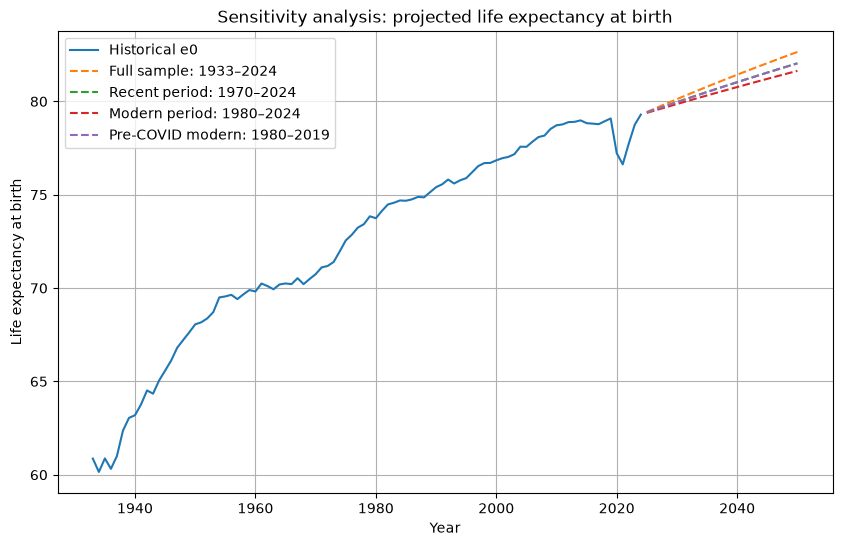

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(historical_e0.index, historical_e0.values, label="Historical e0")

for name, k_forecast_scenario in scenario_forecasts.items():
    mx_forecast_scenario = build_adjusted_mortality_forecast(
        mx_100=mx_100,
        b_x=b_x,
        k_t=k_t,
        k_forecast=k_forecast_scenario,
        base_year=2024
    )
    
    e0_scenario = {}
    
    for year in mx_forecast_scenario.columns:
        lt = build_life_table(mx_forecast_scenario[year])
        e0_scenario[year] = lt.loc[0, "e_x"]
    
    e0_scenario = pd.Series(e0_scenario)
    
    plt.plot(
        e0_scenario.index,
        e0_scenario.values,
        linestyle="--",
        label=name
    )

plt.xlabel("Year")
plt.ylabel("Life expectancy at birth")
plt.title("Sensitivity analysis: projected life expectancy at birth")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
display(scenario_stats)
display(sensitivity_results)

,Scenario,Start Year,End Year,Drift,Sigma
0,Full sample: 1933–2024,1933,2024,-1.332007,2.346400
1,Recent period: 1970–2024,1970,2024,-1.073157,2.315510
2,Modern period: 1980–2024,1980,2024,-0.904087,2.461397
3,Pre-COVID modern: 1980–2019,1980,2019,-1.069057,1.383989


,Scenario,e0_2030,e0_2040,e0_2050,e65_2030,e65_2040,e65_2050
0,Full sample: 1933–2024,80.121348,81.429101,82.649093,20.545821,21.288068,22.003696
1,Recent period: 1970–2024,79.962829,81.032200,82.043243,20.457641,21.060038,21.645564
2,Modern period: 1980–2024,79.858589,80.768288,81.635926,20.399868,20.909737,21.407834
3,Pre-COVID modern: 1980–2019,79.960308,81.025844,82.033476,20.456242,21.056406,21.639835


In [23]:
sensitivity_dir = Path("../data/processed")

scenario_stats.to_csv(sensitivity_dir / "sensitivity_drift_stats.csv", index=False)
sensitivity_results.to_csv(sensitivity_dir / "sensitivity_life_expectancy_results.csv", index=False)

print("Saved sensitivity analysis results.")

Saved sensitivity analysis results.


## Conclusion

The jump-off adjusted forecast connects smoothly to the latest observed mortality experience. Under the baseline forecast, life expectancy at birth is projected to increase from approximately 79.3 years in 2024 to approximately 82.6 years in 2050. Sensitivity analysis shows that the projection depends meaningfully on the historical period used to estimate mortality improvement.